# 01 · Análisis exploratorio del comercio exterior de Chile (2024 – ago 2026)

**Fase CRISP-DM:** comprensión de los datos. Responde la pregunta 1 del proyecto (qué explica la evolución
reciente del comercio y cuán concentrado está), y sus hallazgos definen las reglas de la preparación de datos
(`comercio_chile.clean`).

**Objetivo del notebook:** entender qué contienen los datos, qué tan confiables son y qué patrones van a
condicionar el modelamiento posterior (grafo, forecasting y drift).

**Datos:** registros a nivel ítem de Aduana: DUS (exportaciones) y DIN (importaciones), de enero 2024 a
agosto 2026. La capa `interim` es la copia fiel tipada; la capa `processed` es el panel mensual
`periodo × HS6 × país` construido por `comercio_chile.clean`.

**Convenciones:**
- Exportaciones en **azul**, importaciones en **naranjo**, en todo el proyecto.
- Montos en **millones de US$ (MMUSD)**. Exportaciones = valor FOB, importaciones = valor CIF.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick

from comercio_chile import viz
from comercio_chile.config import INTERIM, PROCESSED
from comercio_chile.data import load, hs_chapters, country_names
from comercio_chile.references import load as ref

viz.setup()
pd.set_option("display.width", 200)
pd.set_option("display.float_format", lambda x: f"{x:,.1f}")

CAP = hs_chapters()
PAIS = country_names()
pe = pd.read_parquet(PROCESSED / "panel_exportaciones.parquet")
pi = pd.read_parquet(PROCESSED / "panel_importaciones.parquet")
for p in (pe, pi):
    p["periodo"] = pd.PeriodIndex(p["periodo"], freq="M") if not isinstance(p["periodo"].dtype, pd.PeriodDtype) else p["periodo"]
peb = pe[pe.segmento == "bienes"]          # exportaciones de BIENES (análisis principal)
print(f"Panel exportaciones: {len(pe):,} filas | importaciones: {len(pi):,} filas")
print("Periodos:", pe.periodo.min(), "→", pe.periodo.max(), f"({pe.periodo.nunique()} meses)")

Panel exportaciones: 251,200 filas | importaciones: 878,710 filas
Periodos: 2024-01 → 2026-08 (32 meses)


## 1. Calidad de la ingesta

Antes de analizar, verificamos que la lectura de los archivos crudos no haya perdido ni deformado datos.
`ingest.py` registra por archivo cuántas líneas se repararon y cuántos valores no se pudieron convertir.

In [2]:
log = pd.read_csv(INTERIM / "_ingest_log.csv")
cols = ["rows", "lines_joined", "lines_padded", "invalid_rows", "numeric_coerced", "date_coerced", "rows_outside_month"]
log.groupby("kind")[cols].sum()

,rows,lines_joined,lines_padded,invalid_rows,numeric_coerced,date_coerced,rows_outside_month
kind,,,,,,,
exportaciones,3152344,0,171,0,0,0,0
importaciones,12456918,9,38,0,0,0,0


**Lectura:**
- **0 filas descartadas** (`invalid_rows`), **0 montos o fechas no convertibles** y **0 filas fuera del mes** de su archivo.
- `lines_joined`: registros DIN partidos por un salto de línea dentro de `NUM_CONOC`, que se volvieron a unir.
- `lines_padded`: registros truncados en origen. En la DUS el corte ocurre después de la descripción del
  ítem, así que el encabezado queda íntegro y los campos del ítem quedan nulos. Su valor se reconstruye en
  `clean.py` (regla R2).

## 2. Granularidad y una trampa de agregación

Cada fila es un **ítem** de una declaración. Los montos del encabezado (`TOTALVALORFOB`, `CIF`) se repiten en
todos los ítems, así que sumarlos multiplica el valor de las declaraciones con muchos ítems. Lo comprobamos:

In [3]:
ex = load("exportaciones", ["NUMEROIDENT", "TIPOOPERACION", "FOBUS", "TOTALVALORFOB"], periods=["2025-03"])
bien = ex[ex.TIPOOPERACION == "200"]
correcto = bien.FOBUS.sum() / 1e6
inflado = bien.TOTALVALORFOB.sum() / 1e6
print(f"Mar-2025, suma de FOBUS (ítem):              {correcto:>10,.0f} MMUSD")
print(f"Mar-2025, suma de TOTALVALORFOB (encabezado): {inflado:>10,.0f} MMUSD  (x{inflado/correcto:.1f} inflado)")
print(f"Ítems por declaración: mediana {bien.groupby('NUMEROIDENT').size().median():.0f}, "
      f"máximo {bien.groupby('NUMEROIDENT').size().max():,}")

Mar-2025, suma de FOBUS (ítem):                   8,706 MMUSD
Mar-2025, suma de TOTALVALORFOB (encabezado):     16,015 MMUSD  (x1.8 inflado)
Ítems por declaración: mediana 1, máximo 693


Sumar el encabezado casi **duplica** el total (×1,8). El efecto es "solo" ×1,8 porque la mayoría de las
declaraciones tiene un ítem, pero las que tienen cientos multiplican su valor cientos de veces. Todo el proyecto agrega **solo valores a nivel ítem**
(`FOBUS`, `CIF_ITEM`).

**Validación externa:** con esta regla, las exportaciones totales de 2024 suman ≈ US$ 99.600 millones,
consistente con la cifra anual publicada por el Banco Central (≈ US$ 100 mil millones). Que el total
calce con una fuente independiente es la mejor evidencia de que la ingesta y la agregación son correctas.

In [4]:
anual = pd.DataFrame({
    "Exportaciones (FOB, todas)": pe.groupby(pe.periodo.dt.year).valor_usd.sum() / 1e6,
    "Exportaciones de bienes": peb.groupby(peb.periodo.dt.year).valor_usd.sum() / 1e6,
    "Importaciones (CIF)": pi.groupby(pi.periodo.dt.year).valor_usd.sum() / 1e6,
})
anual.index.name = "año (2026 = ene-ago)"
anual.round(0)

,"Exportaciones (FOB, todas)",Exportaciones de bienes,Importaciones (CIF)
año (2026 = ene-ago),,,
2024,"99,629.0","96,196.0","78,446.0"
2025,"107,027.0","103,121.0","85,672.0"
2026,"89,222.0","85,454.0","58,616.0"


## 3. ¿Qué se está declarando? Tipos de operación y segmentos

La DUS no registra solo exportaciones de bienes. También incluye servicios exportados y "rancho"
(combustible y provisiones vendidos a naves extranjeras). Ninguno de los dos usa códigos del Sistema
Armonizado: llevan códigos `00…`.

In [5]:
seg = pe.groupby("segmento").valor_usd.sum().div(1e6).to_frame("MMUSD")
seg["%"] = seg.MMUSD / seg.MMUSD.sum() * 100
seg.sort_values("MMUSD", ascending=False)

,MMUSD,%
segmento,,
bienes,"284,770.7",96.2
servicios,"8,829.7",3.0
rancho,"2,277.9",0.8


In [6]:
items = load("exportaciones", ["TIPOOPERACION", "CODIGOARANCEL", "NOMBRE", "FOBUS"])
items.nlargest(5, "FOBUS")[["periodo", "TIPOOPERACION", "CODIGOARANCEL", "NOMBRE", "FOBUS"]]

,periodo,TIPOOPERACION,CODIGOARANCEL,NOMBRE,FOBUS
2465547,2026-01,211,00160000,SIN-CODIGO ~ COMBUSTIBLES PARA NAVES DE ...,"484,063,712.0"
2965329,2026-07,200,74020013,SIN-CODIGO ~ ANODO DE COBRE~ ALTONORTE-F~...,"176,330,815.6"
2646881,2026-03,200,74020013,SIN-CODIGO ~ ANODO DE COBRE~ ALTONORTE-F~...,"169,122,253.1"
2676933,2026-04,200,74020013,SIN-CODIGO ~ ANODO DE COBRE~ ALTONORTE-F~...,"166,699,982.8"
2677297,2026-04,200,74020013,SIN-CODIGO ~ ANODO DE COBRE~ ALTONORTE-F~...,"163,003,635.8"


**El ítem más grande de toda la base (US$ 484 millones, ene-2026) es combustible vendido a naves
(rancho).** Si no separamos segmentos, un solo registro de este tipo distorsiona el total del mes y cualquier
análisis por producto. **Decisión:** el análisis de comercio de bienes usa solo `segmento == "bienes"`.
Servicios y rancho se reportan aparte.

## 4. Evolución mensual

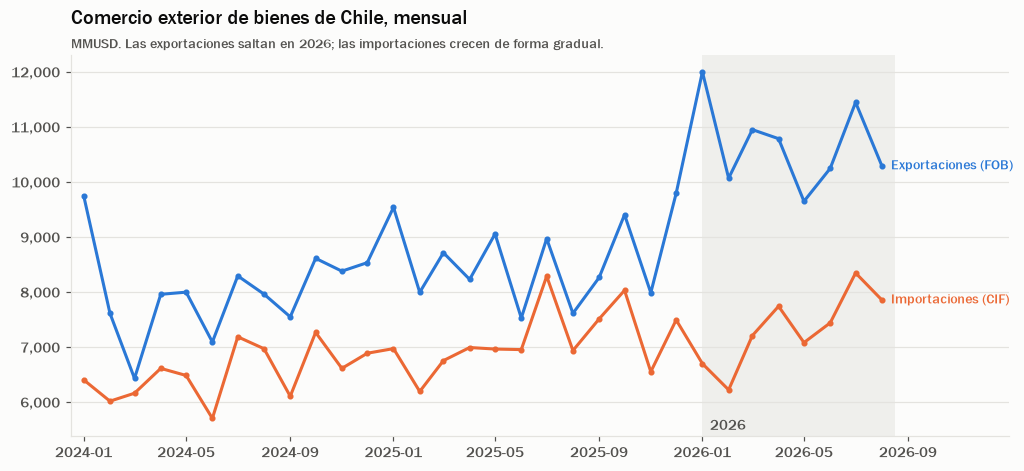

In [7]:
m_exp = peb.groupby("periodo").valor_usd.sum() / 1e6
m_imp = pi.groupby("periodo").valor_usd.sum() / 1e6
x = m_exp.index.to_timestamp()

fig, ax = plt.subplots(figsize=(11, 4.5))
ax.plot(x, m_exp.values, color=viz.EXPORT, marker="o", markersize=3)
ax.plot(x, m_imp.values, color=viz.IMPORT, marker="o", markersize=3)
viz.label_end(ax, x[-1], m_exp.iloc[-1], "Exportaciones (FOB)", viz.EXPORT)
viz.label_end(ax, x[-1], m_imp.iloc[-1], "Importaciones (CIF)", viz.IMPORT)
ax.axvspan(pd.Timestamp("2026-01-01"), x[-1] + pd.Timedelta(days=15), color=viz.GRID, alpha=0.5, lw=0)
ax.text(pd.Timestamp("2026-01-10"), ax.get_ylim()[0] * 1.01, "2026", color=viz.TEXT_2, va="bottom")
ax.set_title("Comercio exterior de bienes de Chile, mensual")
viz.subtitle(ax, "MMUSD. Las exportaciones saltan en 2026; las importaciones crecen de forma gradual.")
ax.yaxis.set_major_formatter(mtick.StrMethodFormatter("{x:,.0f}"))
ax.set_xlim(x[0] - pd.Timedelta(days=15), x[-1] + pd.Timedelta(days=150))
viz.save(fig, "01_serie_mensual"); fig

In [8]:
def ene_ago(s):
    s = s[s.index.month <= 8]
    return s.groupby(s.index.year).sum()
pd.DataFrame({"exportaciones": ene_ago(m_exp), "importaciones": ene_ago(m_imp)}).assign(
    var_exp=lambda d: d.exportaciones.pct_change() * 100, var_imp=lambda d: d.importaciones.pct_change() * 100
).round(1).rename_axis("ene–ago")

,exportaciones,importaciones,var_exp,var_imp
ene–ago,,,,
2024,"63,111.9","51,562.5",NaN,NaN
2025,"67,661.3","56,074.5",7.2,8.8
2026,"85,454.4","58,616.0",26.3,4.5


**Las exportaciones de bienes crecen +26% en ene–ago 2026, mientras las importaciones crecen +4,5%.**
Un salto de esa magnitud en exportaciones necesita explicación antes de modelar: ¿Chile exportó más
cantidad, o lo mismo a mejores precios?

## 5. ¿Qué explica el salto de 2026? Precio vs. volumen

Separamos el aumento por capítulo del Sistema Armonizado y luego descomponemos el caso del cobre en
**valor unitario** (US$/kg) y **volumen** (kg), comparando el mismo período ene–ago de cada año.

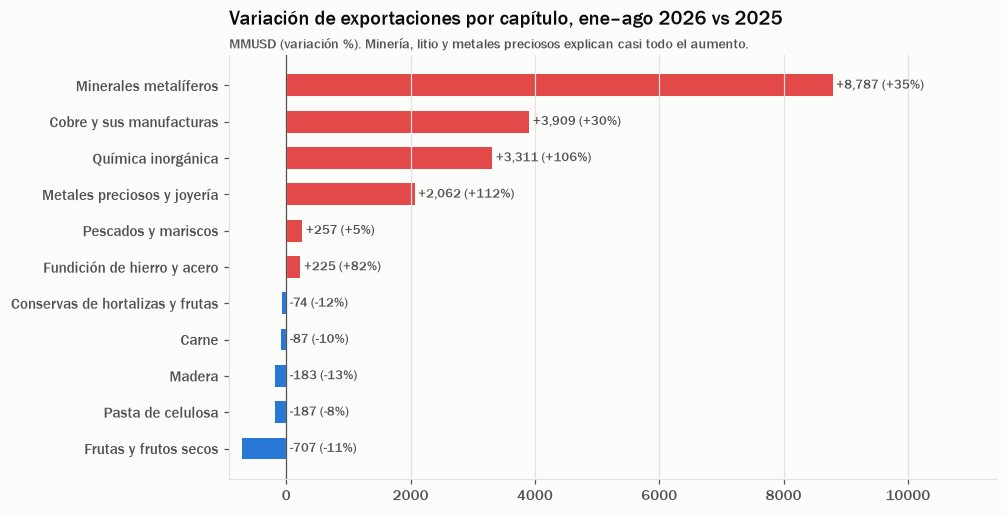

In [9]:
e8 = peb[peb.periodo.dt.month <= 8]
t = e8.pivot_table(index="capitulo", columns=e8.periodo.dt.year, values="valor_usd", aggfunc="sum") / 1e6
t["delta"] = t[2026] - t[2025]
t["var_%"] = (t[2026] / t[2025] - 1) * 100
t["glosa"] = CAP.reindex(t.index).values
top = pd.concat([t.nlargest(6, "delta"), t.nsmallest(5, "delta")]).sort_values("delta")

fig, ax = plt.subplots(figsize=(9, 5))
colors = [viz.DIVERGING[2] if v > 0 else viz.DIVERGING[0] for v in top.delta]
ax.barh(top.glosa, top.delta, color=colors, height=0.6)
for y, (v, p) in enumerate(zip(top.delta, top["var_%"])):
    ax.text(max(v, 0) + 60, y, f"{v:+,.0f} ({p:+.0f}%)", va="center", ha="left", fontsize=8.5, color=viz.TEXT_2)
ax.axvline(0, color=viz.TEXT_2, lw=0.8)
ax.grid(axis="y", visible=False); ax.grid(axis="x", visible=True)
ax.set_xlim(top.delta.min() * 1.3, top.delta.max() * 1.3)
ax.set_title("Variación de exportaciones por capítulo, ene–ago 2026 vs 2025")
viz.subtitle(ax, "MMUSD (variación %). Minería, litio y metales preciosos explican casi todo el aumento.")
viz.save(fig, "02_contribucion_crecimiento"); fig

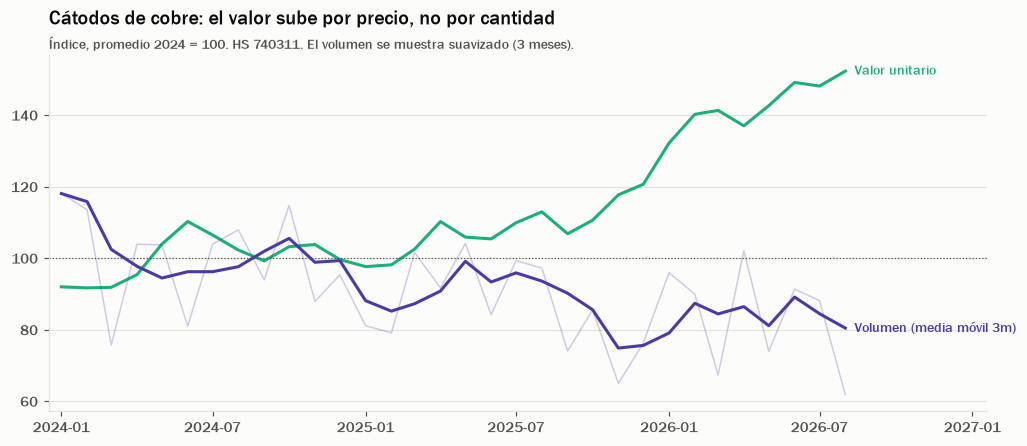

In [10]:
cu = items[items.CODIGOARANCEL.str.startswith("740311", na=False)]  # cátodos de cobre refinado
peso = load("exportaciones", ["CODIGOARANCEL", "PESOBRUTOITEM"])
peso = peso[peso.CODIGOARANCEL.str.startswith("740311", na=False)].groupby("periodo").PESOBRUTOITEM.sum()
cu_m = pd.DataFrame({"fob": cu.groupby("periodo").FOBUS.sum(), "kg": peso})
cu_m["usd_kg"] = cu_m.fob / cu_m.kg
base = cu_m.loc[cu_m.index.year == 2024].mean()
idx = pd.DataFrame({"Valor unitario (US$/kg)": cu_m.usd_kg / base.usd_kg * 100,
                    "Volumen (kg)": cu_m.kg / base.kg * 100})
x = idx.index.to_timestamp()

fig, ax = plt.subplots(figsize=(11, 4.2))
ax.plot(x, idx.iloc[:, 0], color=viz.SERIES[2])
ax.plot(x, idx.iloc[:, 1].rolling(3, min_periods=1).mean(), color=viz.SERIES[6])
ax.plot(x, idx.iloc[:, 1], color=viz.SERIES[6], alpha=0.25, lw=1)
ax.axhline(100, color=viz.TEXT_2, lw=0.8, ls=":")
viz.label_end(ax, x[-1], idx.iloc[-1, 0], "Valor unitario", viz.SERIES[2])
viz.label_end(ax, x[-1], idx.iloc[-3:, 1].mean(), "Volumen (media móvil 3m)", viz.SERIES[6])
ax.set_xlim(x[0] - pd.Timedelta(days=15), x[-1] + pd.Timedelta(days=170))
ax.xaxis.set_major_locator(plt.matplotlib.dates.MonthLocator(bymonth=[1, 7]))
ax.set_title("Cátodos de cobre: el valor sube por precio, no por cantidad")
viz.subtitle(ax, "Índice, promedio 2024 = 100. HS 740311. El volumen se muestra suavizado (3 meses).")
viz.save(fig, "03_cobre_precio_volumen"); fig

**El crecimiento de 2026 es de precios.** El valor unitario de los cátodos de cobre sube ~40% sobre el
promedio 2024, mientras el volumen se mantiene o cae. El mismo patrón aparece en química inorgánica
(litio, +106%) y metales preciosos (+112%). La fruta, la celulosa, la madera y el vino **caen**.

**Implicancias:**
1. **Modelamiento:** el valor exportado = precio × cantidad, y el precio de los commodities es **exógeno**
   (se fija en mercados internacionales) y no está en nuestros datos. Un modelo entrenado con 2024–2025
   tenderá a subestimar 2026. Por eso conviene evaluar por separado commodities y no-commodities, y
   considerar el volumen como objetivo alternativo.
2. **Drift monitoring:** 2026 es un **cambio de régimen real y documentado**, un caso de validación natural
   para el sistema de monitoreo (entrenar con 2024–2025 y "desplegar" en 2026).
3. **Interpretación:** +26% nominal no significa que se exportó 26% más mercancía.

## 6. Composición: qué exporta e importa Chile

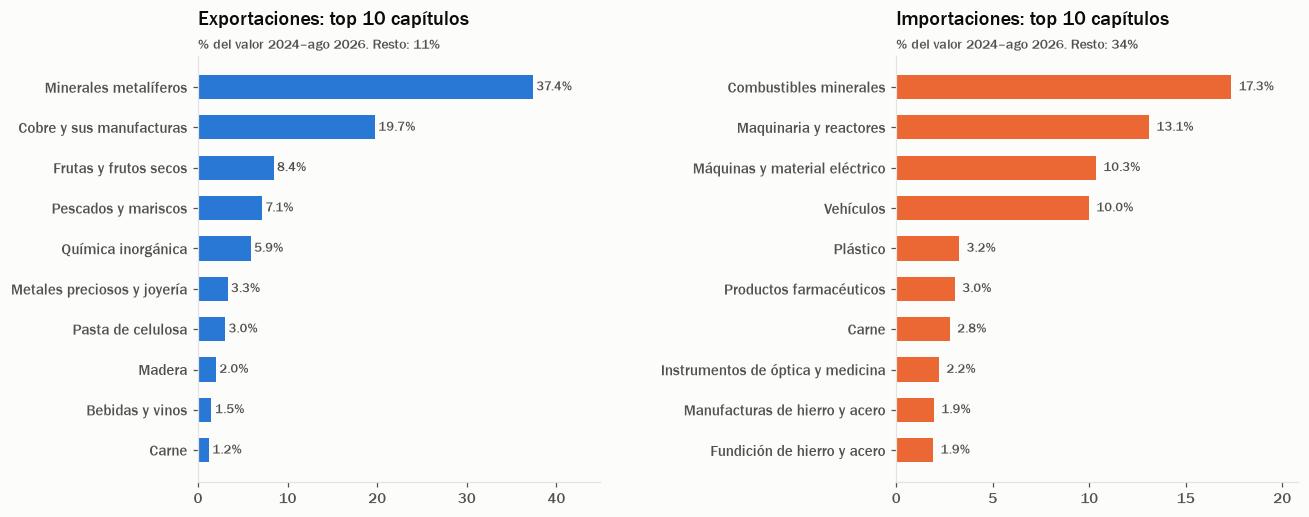

In [11]:
def top_chapters(panel, n=10):
    s = panel.groupby("capitulo").valor_usd.sum()
    s = (s / s.sum() * 100).sort_values(ascending=False)
    out = s.head(n)
    out.index = [CAP.get(c, c) for c in out.index]
    return out, s.iloc[n:].sum()

fig, axes = plt.subplots(1, 2, figsize=(12, 4.8))
for ax, panel, color, title in [(axes[0], peb, viz.EXPORT, "Exportaciones"), (axes[1], pi, viz.IMPORT, "Importaciones")]:
    s, rest = top_chapters(panel)
    ax.barh(s.index[::-1], s.values[::-1], color=color, height=0.6)
    for y, v in enumerate(s.values[::-1]):
        ax.text(v + 0.4, y, f"{v:.1f}%", va="center", fontsize=8.5, color=viz.TEXT_2)
    ax.grid(axis="y", visible=False); ax.set_xlim(0, s.max() * 1.2)
    ax.set_title(f"{title}: top 10 capítulos")
    viz.subtitle(ax, f"% del valor 2024–ago 2026. Resto: {rest:.0f}%")
fig.tight_layout(w_pad=4)
viz.save(fig, "04_composicion_capitulos"); fig

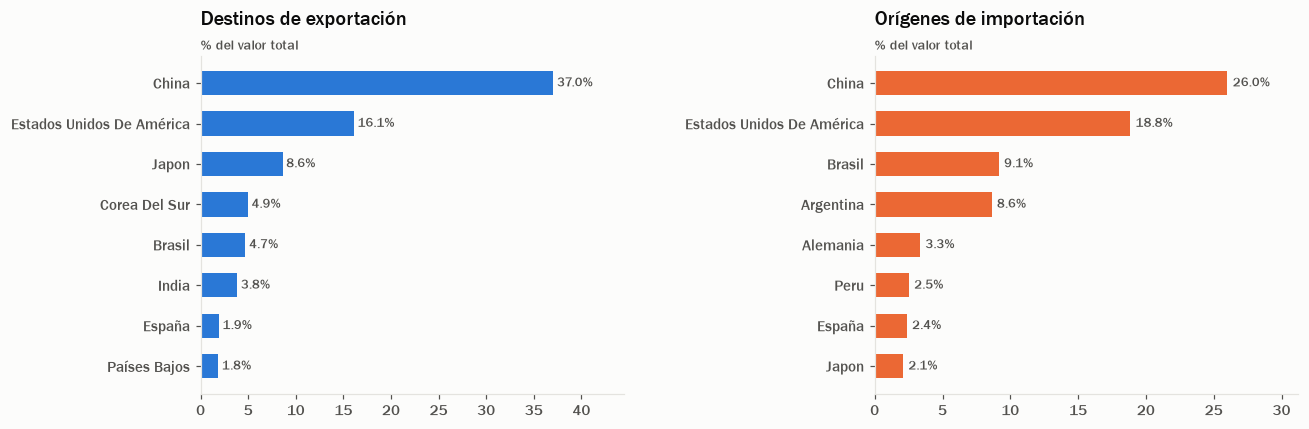

In [12]:
def top_partners(panel, n=8):
    s = panel[~panel.pseudo_pais].groupby("pais").valor_usd.sum()
    s = (s / panel.valor_usd.sum() * 100).sort_values(ascending=False).head(n)
    s.index = [PAIS.get(c, c).title() for c in s.index]
    return s

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, panel, color, title in [(axes[0], peb, viz.EXPORT, "Destinos de exportación"), (axes[1], pi, viz.IMPORT, "Orígenes de importación")]:
    s = top_partners(panel)
    ax.barh(s.index[::-1], s.values[::-1], color=color, height=0.6)
    for y, v in enumerate(s.values[::-1]):
        ax.text(v + 0.4, y, f"{v:.1f}%", va="center", fontsize=8.5, color=viz.TEXT_2)
    ax.grid(axis="y", visible=False); ax.set_xlim(0, s.max() * 1.2)
    ax.set_title(title); viz.subtitle(ax, "% del valor total")
fig.tight_layout(w_pad=4)
viz.save(fig, "05_socios"); fig

**Lectura:**
- Las **exportaciones** dependen de pocos productos: minerales de cobre (cap. 26) y cobre refinado (cap. 74)
  suman más de la mitad. China recibe más de un tercio.
- Las **importaciones** están mucho más repartidas: combustibles, maquinaria, vehículos y equipos eléctricos.
- **Pseudo-países:** en los gráficos de socios se excluyen los códigos ≥ 900 y el 997 (rancho, orígenes
  varios, zonas francas, Chile), porque no representan países. En importaciones, "904 – Orígenes varios"
  suma ~US$ 470 millones en 2026; en el grafo crearía un nodo artificial muy conectado.

## 7. Concentración

La concentración define cómo evaluar los modelos. Si pocas series concentran el valor, el error
**ponderado por valor** importa más que el error promedio por serie.

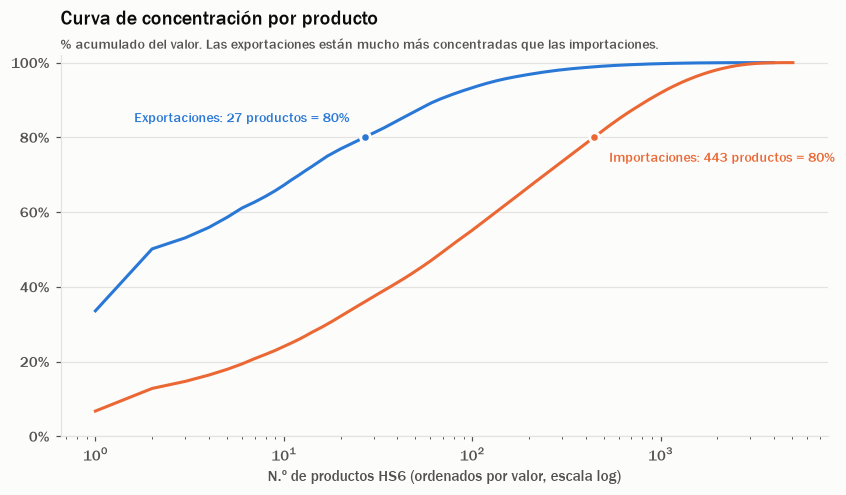

,productos HS6,top 10 (%),n para 80%,n para 95%
flujo,,,,
Exportaciones,3980,67.2,27,132
Importaciones,5042,24.0,443,1334


In [13]:
fig, ax = plt.subplots(figsize=(9, 4.5))
rows = []
for panel, color, name in [(peb, viz.EXPORT, "Exportaciones"), (pi, viz.IMPORT, "Importaciones")]:
    s = panel.groupby("hs6").valor_usd.sum().sort_values(ascending=False)
    cs = (s.cumsum() / s.sum()).values * 100
    ax.plot(np.arange(1, len(cs) + 1), cs, color=color)
    n80 = int(np.argmax(cs >= 80)) + 1
    ax.scatter([n80], [80], color=color, s=40, zorder=3, edgecolor=viz.SURFACE, linewidth=2)
    ax.annotate(f"{name}: {n80} productos = 80%", (n80, 80), xytext=(-10, 10) if name == "Exportaciones" else (10, -16), ha="right" if name == "Exportaciones" else "left",
                textcoords="offset points", color=color, fontsize=9, fontweight="bold")
    rows.append({"flujo": name, "productos HS6": len(s), "top 10 (%)": cs[9], "n para 80%": n80,
                 "n para 95%": int(np.argmax(cs >= 95)) + 1})
ax.set_xscale("log"); ax.set_ylim(0, 102)
ax.set_xlabel("N.º de productos HS6 (ordenados por valor, escala log)")
ax.yaxis.set_major_formatter(mtick.PercentFormatter())
ax.set_title("Curva de concentración por producto")
viz.subtitle(ax, "% acumulado del valor. Las exportaciones están mucho más concentradas que las importaciones.")
viz.save(fig, "06_concentracion"); display(fig); plt.close(fig)
pd.DataFrame(rows).set_index("flujo")

In [14]:
# Concentración por empresa: válida solo dentro de cada mes (IDs renumerados mes a mes)
emp = load("exportaciones", ["NRO_EXPORTADOR", "FOBUS", "TIPOOPERACION"], periods=["2025-03", "2026-03"])
emp = emp[emp.TIPOOPERACION == "200"]
res = []
for p, g in emp.groupby("periodo"):
    s = g.groupby("NRO_EXPORTADOR").FOBUS.sum().sort_values(ascending=False)
    sh = s / s.sum()
    res.append({"periodo": str(p), "exportadores": len(s), "top 10 (%)": sh.head(10).sum() * 100,
                "HHI": (sh ** 2).sum() * 10_000})
pd.DataFrame(res).set_index("periodo")

,exportadores,top 10 (%),HHI
periodo,,,
2025-03,2748,49.3,576.3
2026-03,2921,47.8,450.4


**HHI** (índice Herfindahl-Hirschman) = suma de las participaciones al cuadrado × 10.000. Va de ~0
(competencia atomizada) a 10.000 (monopolio); las guías de competencia consideran "no concentrado" un HHI
bajo 1.000. Aquí hay un **matiz interesante**: 10 empresas generan ~48% del valor de cada mes, pero el HHI es
bajo (~450–580) porque ninguna empresa domina sola y hay una cola de ~2.900 exportadoras. Al elevar al cuadrado
las participaciones, el HHI castiga más la dominancia de **una** empresa que la existencia de varias grandes.
Por eso conviene reportar ambas métricas: una sola cifra no describe bien la estructura del mercado.

## 8. Los IDs de empresa se renumeran cada mes

El diccionario dice que el RUT del exportador/importador se entrega "como número único correlativo".
¿Es estable entre meses? Lo comprobamos con un atributo que debería ser fijo para una empresa: su comuna.

In [15]:
def id_stability(kind, id_col, attr):
    df = load(kind, [id_col, attr]).drop_duplicates()
    within = (df.groupby(["periodo", id_col])[attr].nunique() == 1).mean()
    g = df.groupby(id_col).agg(n_meses=("periodo", "nunique"), n_attr=(attr, "nunique"))
    multi = g[g.n_meses >= 2]
    ids_max = df.groupby("periodo")[id_col].apply(lambda s: pd.to_numeric(s).max())
    ids_n = df.groupby("periodo")[id_col].nunique()
    return {"comuna única dentro del mes (%)": within * 100,
            "comuna única entre meses (%)": (multi.n_attr == 1).mean() * 100,
            "ID máx / n.º IDs (mediana mensual)": (ids_max / ids_n).median()}

pd.DataFrame({
    "Exportadores": id_stability("exportaciones", "NRO_EXPORTADOR", "COMUNAEXPORTADORPPAL"),
    "Importadores": id_stability("importaciones", "NUM_UNICO_IMPORTADOR", "CODCOMUN"),
}).round(2)

,Exportadores,Importadores
comuna única dentro del mes (%),97.6,98.6
comuna única entre meses (%),1.1,0.1
ID máx / n.º IDs (mediana mensual),5.1,1.0


**Conclusión:** dentro de un mes, el ID identifica a una empresa (su comuna es casi siempre única). Entre
meses no: el mismo número corresponde a empresas distintas (consistencia ≈ 0–1%, lo que se esperaría por
azar). En importaciones, el ID máximo ≈ cantidad de importadores del mes, es decir, un correlativo 1…N
por archivo. En exportaciones, los IDs se toman de un rango ~5 veces mayor, pero igual se reasignan cada mes.

**Implicancias** (una vuelta a la comprensión del negocio: las preguntas por empresa quedan fuera del alcance):
- No hay series de tiempo por empresa ni grafos de empresas en el tiempo.
- Las dimensiones estables son producto (HS), país, puerto, aduana y región.
- Se descarta intentar re-identificar empresas: la anonimización es intencional.

## 9. Estacionalidad

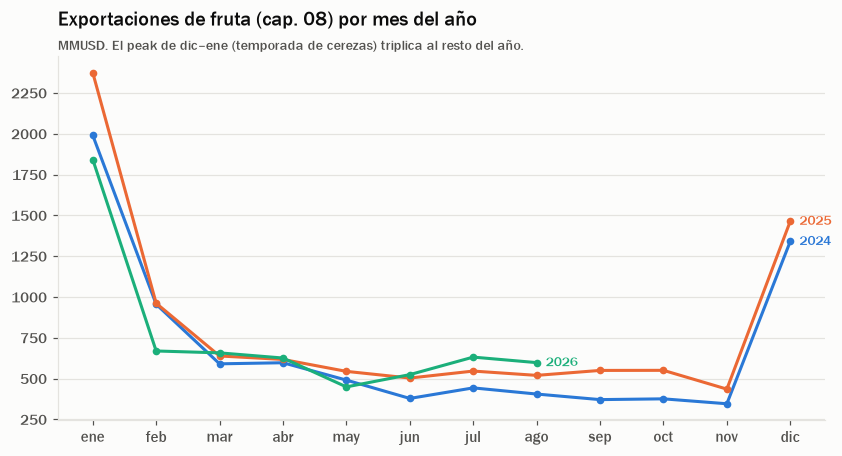

In [16]:
fruta = peb[peb.capitulo == "08"].groupby("periodo").valor_usd.sum() / 1e6
fr = pd.DataFrame({"v": fruta.values, "y": fruta.index.year, "m": fruta.index.month})

fig, ax = plt.subplots(figsize=(9, 4.3))
for i, (y, g) in enumerate(fr.groupby("y")):
    ax.plot(g.m, g.v, color=viz.SERIES[i], marker="o", markersize=4)
    viz.label_end(ax, g.m.iloc[-1], g.v.iloc[-1], str(y), viz.SERIES[i])
ax.set_xticks(range(1, 13), ["ene", "feb", "mar", "abr", "may", "jun", "jul", "ago", "sep", "oct", "nov", "dic"])
ax.set_title("Exportaciones de fruta (cap. 08) por mes del año")
viz.subtitle(ax, "MMUSD. El peak de dic–ene (temporada de cerezas) triplica al resto del año.")
viz.save(fig, "07_estacionalidad_fruta"); fig

In [17]:
# Fuerza estacional por capítulo: correlación entre el valor de cada mes y el del mismo mes un año antes,
# versus la correlación con el mes inmediatamente anterior (sobre el panel mensual por capítulo).
cm = peb.pivot_table(index="periodo", columns="capitulo", values="valor_usd", aggfunc="sum").fillna(0)
cm = cm.loc[:, cm.sum().sort_values(ascending=False).index[:12]]
lag = pd.DataFrame({
    "corr lag 1": cm.apply(lambda s: s.corr(s.shift(1))),
    "corr lag 12": cm.apply(lambda s: s.corr(s.shift(12))),
})
lag.index = [CAP.get(c, c) for c in lag.index]
lag.round(2)

,corr lag 1,corr lag 12
Minerales metalíferos,0.6,0.3
Cobre y sus manufacturas,0.2,-0.1
Frutas y frutos secos,0.4,0.9
Pescados y mariscos,0.6,0.8
Química inorgánica,0.8,-0.3
Metales preciosos y joyería,0.8,0.5
Pasta de celulosa,0.2,0.3
Madera,0.3,0.0
Bebidas y vinos,0.0,0.6
Carne,0.2,0.4


**Lectura:** hay dos regímenes claramente distintos.
- **Estacionales** (lag 12 > lag 1): fruta (0,9 vs 0,4), vino (0,6 vs 0,0), pescados, carne y conservas.
  Su ciclo es biológico o de temporada.
- **Persistentes** (lag 1 > lag 12): química inorgánica/litio (0,8), metales preciosos y minerales. Su
  dinámica la mueven los precios internacionales y la producción minera, no el calendario.
- Cobre refinado, celulosa y madera muestran correlaciones bajas en ambos rezagos: series ruidosas, donde
  ningún baseline simple va a funcionar bien.

*Ojo:* con 32 meses cada correlación se calcula con 20–31 pares de puntos, así que estas cifras son
orientativas, no estimaciones precisas.

**Implicancia:** cualquier modelo de forecasting debe compararse contra **dos baselines**: el *naive*
(valor del mes anterior) y el *naive estacional* (valor del mismo mes del año anterior). Las features
deben incluir el rezago 12, que existe gracias a los datos 2024–2025.

## 10. Intermitencia de las series producto × país

In [18]:
def intermittency(panel):
    s = panel[~panel.pseudo_pais].groupby(["hs6", "pais"]).agg(meses=("periodo", "nunique"), valor=("valor_usd", "sum"))
    b = pd.cut(s.meses, [0, 3, 12, 24, 31, 32], labels=["1–3", "4–12", "13–24", "25–31", "32 (todos)"])
    out = s.groupby(b, observed=False).agg(series=("valor", "size"), valor=("valor", "sum"))
    out["% series"] = out.series / out.series.sum() * 100
    out["% valor"] = out.valor / out.valor.sum() * 100
    return out[["series", "% series", "% valor"]]

pd.concat({"Exportaciones": intermittency(peb), "Importaciones": intermittency(pi)}, axis=1).rename_axis("meses con comercio")

Exportaciones                  Importaciones                 
                          series % series % valor        series % series % valor
meses con comercio                                                              
1–3                        20879     56.8     0.7         39447     45.8     0.9
4–12                        9147     24.9     3.4         21502     24.9     3.0
13–24                       3971     10.8    10.7         11554     13.4     6.9
25–31                       1766      4.8    12.8          7011      8.1    14.5
32 (todos)                  1017      2.8    72.3          6690      7.8    74.7

**La mayoría de las relaciones producto–país son esporádicas, pero el valor está en las regulares.**
En exportaciones, más de la mitad de las series aparece en 3 meses o menos y aporta muy poco valor; las que
aparecen los 32 meses concentran ~70% del valor.

Esto sugiere **dos problemas predictivos distintos**:
- **Regresión:** ¿cuánto se comerciará el próximo mes en las series regulares? (ahí está el valor).
- **Clasificación:** ¿estará activa el próximo mes una relación producto–país? (dinámica de
  entrada/salida de flujos, donde el "cuánto" no tiene sentido porque la mayoría de los meses vale 0).

## 11. Distribución de los valores por ítem

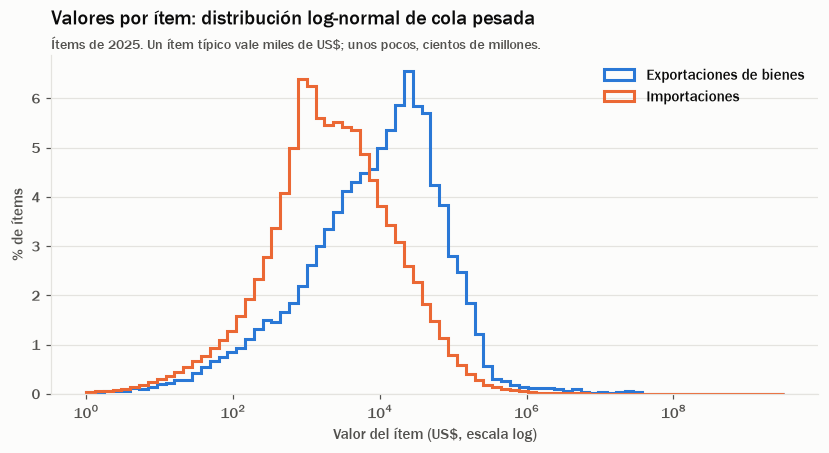

,count,mean,std,min,50%,90%,99%,99.9%,max
exportaciones 2025,"1,139,766.0","90,401.1","1,038,616.4","-11,178.5","11,040.0","89,900.2","755,456.5","20,077,131.8","135,674,749.7"
importaciones 2025,"4,847,013.0","17,675.2","276,043.3",0.0,"2,089.6","26,395.0","186,728.7","1,382,998.7","98,459,544.2"


In [19]:
iv = items.loc[(items.TIPOOPERACION == "200") & (items.periodo.dt.year == 2025), "FOBUS"].dropna()
imp_v = load("importaciones", ["CIF_ITEM"], periods=[f"2025-{m:02d}" for m in range(1, 13)]).CIF_ITEM.dropna()

fig, ax = plt.subplots(figsize=(9, 4))
bins = np.logspace(0, 9.5, 80)
w_e = np.full((iv > 0).sum(), 100 / (iv > 0).sum()); w_i = np.full((imp_v > 0).sum(), 100 / (imp_v > 0).sum())
ax.hist(iv[iv > 0], bins=bins, weights=w_e, histtype="step", lw=2, color=viz.EXPORT, label="Exportaciones de bienes")
ax.hist(imp_v[imp_v > 0], bins=bins, weights=w_i, histtype="step", lw=2, color=viz.IMPORT, label="Importaciones")
ax.set_xscale("log"); ax.legend(loc="upper right")
ax.set_xlabel("Valor del ítem (US$, escala log)"); ax.set_ylabel("% de ítems")
ax.set_title("Valores por ítem: distribución log-normal de cola pesada")
viz.subtitle(ax, "Ítems de 2025. Un ítem típico vale miles de US$; unos pocos, cientos de millones.")
viz.save(fig, "08_distribucion_items"); display(fig); plt.close(fig)
pd.DataFrame({"exportaciones 2025": iv.describe(percentiles=[.5, .9, .99, .999]),
              "importaciones 2025": imp_v.describe(percentiles=[.5, .9, .99, .999])}).T

**Lectura:** los valores se distribuyen aproximadamente log-normales, con varios órdenes de magnitud de
diferencia. **Implicancias:**
- Para modelar se trabajará en **escala logarítmica** (`log1p`). En escala lineal, el error estaría
  dominado por unas pocas series gigantes y el modelo ignoraría el resto.
- Los valores extremos **no son errores**: son embarques reales de cobre, combustible o mineral. No se
  eliminan como outliers. Se detectan anomalías relativas a cada serie, no absolutas.

## 12. Otras verificaciones de calidad

In [20]:
checks = {}
for kind, decl, item, val, head in [("exportaciones", "NUMEROIDENT", "NUMEROITEM", "FOBUS", "TOTALVALORFOB"),
                                    ("importaciones", "NUMENCRIPTADO", "NUMITEM", "CIF_ITEM", "CIF")]:
    d = load(kind, [decl, item, val, head])
    g = d.groupby(["periodo", decl]).agg(s=(val, "sum"), h=(head, "first"), nn=(val, lambda x: x.isna().sum()))
    rel = (g.s / g.h - 1).abs()
    checks[kind] = {
        "ítems": len(d),
        "duplicados (decl, ítem, mes)": int(d.duplicated(["periodo", decl, item]).sum()),
        "ítems con valor nulo (truncados)": int(d[val].isna().sum()),
        "ítems con valor negativo (ajustes)": int((d[val] < 0).sum()),
        "decl. donde Σítems ≠ encabezado (>1%)": int((rel > 0.01).sum()),
        "  de ellas, con ítem truncado": int(((rel > 0.01) & (g.nn > 0)).sum()),
        "% decl. consistentes": 100 * (1 - (rel > 0.01).mean()),
    }
pd.DataFrame(checks)

,exportaciones,importaciones
ítems,"3,152,344.0","12,456,918.0"
"duplicados (decl, ítem, mes)",0.0,0.0
ítems con valor nulo (truncados),171.0,29.0
ítems con valor negativo (ajustes),71.0,0.0
decl. donde Σítems ≠ encabezado (>1%),440.0,58.0
"de ellas, con ítem truncado",154.0,15.0
% decl. consistentes,100.0,100.0


**Lectura:**
- **Sin duplicados.**
- **Consistencia ítem–encabezado > 99,9%.** Las pocas declaraciones inconsistentes se explican en buena
  parte por ítems truncados en origen.
- **Valores negativos:** son declaraciones de ajuste o rectificación (normalmente toda la declaración es
  negativa). Netean el total y se **conservan**.

## 13. Resumen del EDA y decisiones para la preparación de los datos

| # | Hallazgo | Decisión |
|---|---|---|
| 1 | Los montos de encabezado se repiten por ítem | Agregar solo `FOBUS` / `CIF_ITEM` |
| 2 | La DUS incluye servicios y rancho (códigos `00…`) | Segmentar; el análisis de bienes usa `segmento = bienes` |
| 3 | IDs de empresa renumerados cada mes | Unidades estables: HS6, país, puerto, región; empresa solo dentro del mes |
| 4 | Crecimiento 2026 explicado por precios de commodities | Evaluar commodities por separado; usar 2026 como caso real de drift |
| 5 | Estacionalidad fuerte en agro; persistencia en minería | Baselines naive y naive estacional; rezagos 1 y 12 como features |
| 6 | Concentración extrema en exportaciones | Métricas ponderadas por valor (WAPE) además de por serie |
| 7 | Series producto–país muy intermitentes | Regresión para series regulares + clasificación de actividad |
| 8 | Valores log-normales de cola pesada | Modelar en `log1p`; los extremos no son outliers a eliminar |
| 9 | Pseudo-países (≥ 900, 997) | Excluirlos de análisis de socios y del grafo, de forma explícita |